# Phase 3: DeBERTa-v3-base Evaluation on ANLI Round 2

**Objective:** Evaluate a pre-trained DeBERTa-v3-base NLI model on ANLI Round 2, then perform comprehensive error analysis connecting back to Phase 1 EDA findings.

**Model:** `MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli`
- Fine-tuned on MNLI + Fever-NLI + ANLI (all 3 rounds) — 763,913 NLI pairs
- DeBERTa-v3-base backbone (~86M params) with disentangled attention + RTD pre-training
- Outperforms most *large* models on the ANLI benchmark

**Why this model?** ANLI R2 was created adversarially against RoBERTa. DeBERTa-v3 uses a fundamentally different architecture (disentangled attention) and pre-training objective (replaced token detection), giving it a structural advantage. Training on the combined MNLI + FEVER-NLI + ANLI data is the recipe recommended by the original ANLI paper authors — transfer from diverse NLI data significantly improves performance on adversarial examples.

## Setup and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [5]:
CONFIG = {
    "model_name": "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
    "num_labels": 3,
    "max_length": 256,   # From Phase 1 EDA
    "batch_size": 32,    # For inference — can be larger since no gradients
}

LABEL_MAP = {0: "entailment", 1: "neutral", 2: "contradiction"}
LABEL_NAMES = ["entailment", "neutral", "contradiction"]

# Note: MoritzLaurer's model uses label ordering: contradiction=0, neutral=1, entailment=2
# We need to verify and remap to match ANLI's ordering: entailment=0, neutral=1, contradiction=2
MODEL_LABEL_MAP = None  # Will be set after loading the model

print("=== Configuration ===")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

=== Configuration ===
  model_name: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
  num_labels: 3
  max_length: 256
  batch_size: 32


## Load Model and Tokenizer
This pre-trained model uses `AutoTokenizer` successfully because MoritzLaurer's model card includes properly configured tokenizer files.
If it fails, we fall back to our Phase 1 approach (explicit `DebertaV2Tokenizer` with `vocab_file`).

In [6]:
from transformers import DebertaV2Tokenizer
from huggingface_hub import hf_hub_download

try:
    tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
    print("Loaded tokenizer via AutoTokenizer")
except Exception as e:
    print(f"AutoTokenizer failed: {e}")
    print("Falling back to explicit DebertaV2Tokenizer...")
    spm_path = hf_hub_download(
        repo_id=CONFIG["model_name"],
        filename="spm.model",
    )
    tokenizer = DebertaV2Tokenizer(vocab_file=spm_path, do_lower_case=False)
    print(f"Loaded tokenizer via DebertaV2Tokenizer")

model = AutoModelForSequenceClassification.from_pretrained(CONFIG["model_name"])
model.to(device)
model.eval()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

...

Loaded tokenizer via AutoTokenizer


model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [7]:
# Check model's label mapping
print(f"\nModel label mapping (id2label): {model.config.id2label}")
print(f"Model label mapping (label2id): {model.config.label2id}")


Model label mapping (id2label): {0: 'entailment', 1: 'neutral', 2: 'contradiction'}
Model label mapping (label2id): {'contradiction': 2, 'entailment': 0, 'neutral': 1}


In [8]:
# Build remapping: model label index -> ANLI label index
# ANLI: entailment=0, neutral=1, contradiction=2
# Model may use different ordering
model_id2label = model.config.id2label
REMAP = {}
for model_idx, label_str in model_id2label.items():
    model_idx = int(model_idx)
    label_lower = label_str.lower()
    if "entail" in label_lower:
        REMAP[model_idx] = 0
    elif "neutral" in label_lower:
        REMAP[model_idx] = 1
    elif "contra" in label_lower:
        REMAP[model_idx] = 2

print(f"Remap (model_idx -> ANLI_idx): {REMAP}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1e9:.2f} GB (fp32)")

Remap (model_idx -> ANLI_idx): {0: 0, 1: 1, 2: 2}

Total parameters: 184,424,451
Model size: ~0.74 GB (fp32)


## Load Data

In [9]:
dataset = load_dataset("facebook/anli")

dev_ds = dataset["dev_r2"]
test_ds = dataset["test_r2"]

print(f"Dev:  {len(dev_ds):,} examples")
print(f"Test: {len(test_ds):,} examples")

# Also load as pandas for error analysis later
dev_df = dev_ds.to_pandas()
test_df = test_ds.to_pandas()
for df in [dev_df, test_df]:
    df["label_name"] = df["label"].map(LABEL_MAP)

README.md: 0.00B [00:00, ?B/s]

plain_text/train_r1-00000-of-00001.parqu(…):   0%|          | 0.00/3.14M [00:00<?, ?B/s]

plain_text/dev_r1-00000-of-00001.parquet:   0%|          | 0.00/351k [00:00<?, ?B/s]

plain_text/test_r1-00000-of-00001.parque(…):   0%|          | 0.00/353k [00:00<?, ?B/s]

plain_text/train_r2-00000-of-00001.parqu(…):   0%|          | 0.00/6.53M [00:00<?, ?B/s]

...

Generating test_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Dev:  1,000 examples
Test: 1,000 examples


## Inference

In [10]:
def run_inference(premises, hypotheses, batch_size=32):
    """Run batched inference and return predicted labels + probabilities."""
    all_logits = []

    for i in range(0, len(premises), batch_size):
        batch_premises = premises[i:i+batch_size]
        batch_hypotheses = hypotheses[i:i+batch_size]

        inputs = tokenizer(
            batch_premises,
            batch_hypotheses,
            max_length=CONFIG["max_length"],
            truncation=True,
            padding=True,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        all_logits.append(outputs.logits.cpu())

        if (i // batch_size) % 10 == 0:
            print(f"  Processed {min(i+batch_size, len(premises))}/{len(premises)}")

    logits = torch.cat(all_logits, dim=0)
    probs = torch.softmax(logits, dim=-1).numpy()

    # Get predicted class in model's label space, then remap to ANLI labels
    model_preds = np.argmax(logits.numpy(), axis=-1)
    anli_preds = np.array([REMAP[p] for p in model_preds])

    # Remap probabilities to ANLI ordering: [entailment, neutral, contradiction]
    anli_probs = np.zeros_like(probs)
    for model_idx, anli_idx in REMAP.items():
        anli_probs[:, anli_idx] = probs[:, model_idx]

    return anli_preds, anli_probs

In [11]:
print("Running inference on Dev set...")
dev_preds, dev_probs = run_inference(
    dev_df["premise"].tolist(),
    dev_df["hypothesis"].tolist(),
    batch_size=CONFIG["batch_size"],
)

print("\nRunning inference on Test set...")
test_preds, test_probs = run_inference(
    test_df["premise"].tolist(),
    test_df["hypothesis"].tolist(),
    batch_size=CONFIG["batch_size"],
)

print("\nInference complete!")

Running inference on Dev set...
  Processed 32/1000
  Processed 352/1000
  Processed 672/1000
  Processed 992/1000

Running inference on Test set...
  Processed 32/1000
  Processed 352/1000
  Processed 672/1000
  Processed 992/1000

Inference complete!


## Evaluation Results

In [12]:
def evaluate_results(labels, preds, probs, split_name):
    """Compute and display full evaluation metrics."""
    acc = accuracy_score(labels, preds)
    report = classification_report(labels, preds, target_names=LABEL_NAMES,
                                    digits=4, output_dict=True)
    report_str = classification_report(labels, preds, target_names=LABEL_NAMES, digits=4)

    print(f"\n{'='*60}")
    print(f"  {split_name.upper()} SET RESULTS")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"\n{report_str}")

    return {
        "predictions": preds,
        "labels": labels,
        "probabilities": probs,
        "accuracy": acc,
        "report": report,
    }

In [13]:
dev_labels = dev_df["label"].values
test_labels = test_df["label"].values

dev_results = evaluate_results(dev_labels, dev_preds, dev_probs, "Dev")
test_results = evaluate_results(test_labels, test_preds, test_probs, "Test")


  DEV SET RESULTS
Accuracy: 0.5460 (54.60%)

               precision    recall  f1-score   support

   entailment     0.5343    0.5359    0.5351       334
      neutral     0.5333    0.6006    0.5650       333
contradiction     0.5759    0.5015    0.5361       333

     accuracy                         0.5460      1000
    macro avg     0.5478    0.5460    0.5454      1000
 weighted avg     0.5478    0.5460    0.5454      1000


  TEST SET RESULTS
Accuracy: 0.5460 (54.60%)

               precision    recall  f1-score   support

   entailment     0.5371    0.5629    0.5497       334
      neutral     0.5504    0.5736    0.5618       333
contradiction     0.5512    0.5015    0.5252       333

     accuracy                         0.5460      1000
    macro avg     0.5462    0.5460    0.5455      1000
 weighted avg     0.5462    0.5460    0.5455      1000



## Confusion Matrices

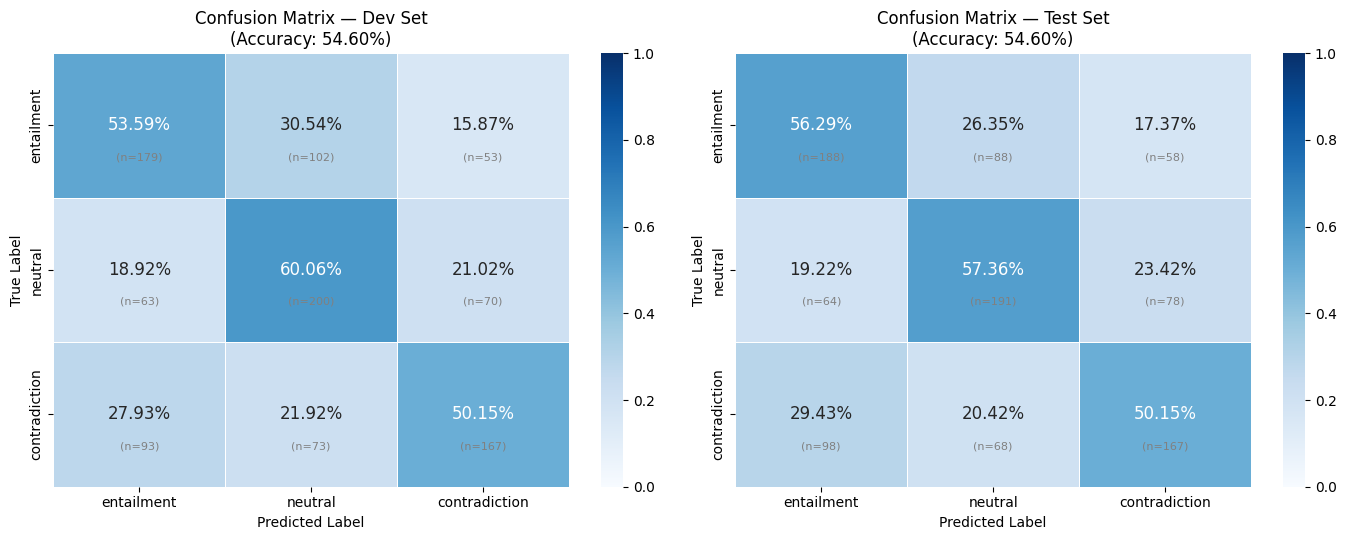

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, results, title in [
    (axes[0], dev_results, "Dev Set"),
    (axes[1], test_results, "Test Set"),
]:
    cm = confusion_matrix(results["labels"], results["predictions"])
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                ax=ax, vmin=0, vmax=1, linewidths=0.5,
                annot_kws={"size": 12})
    for i in range(3):
        for j in range(3):
            ax.text(j + 0.5, i + 0.72, f"(n={cm[i][j]})",
                    ha="center", va="center", fontsize=8, color="gray")
    ax.set_title(f"Confusion Matrix — {title}\n(Accuracy: {results['accuracy']:.2%})")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Per class performance visualization

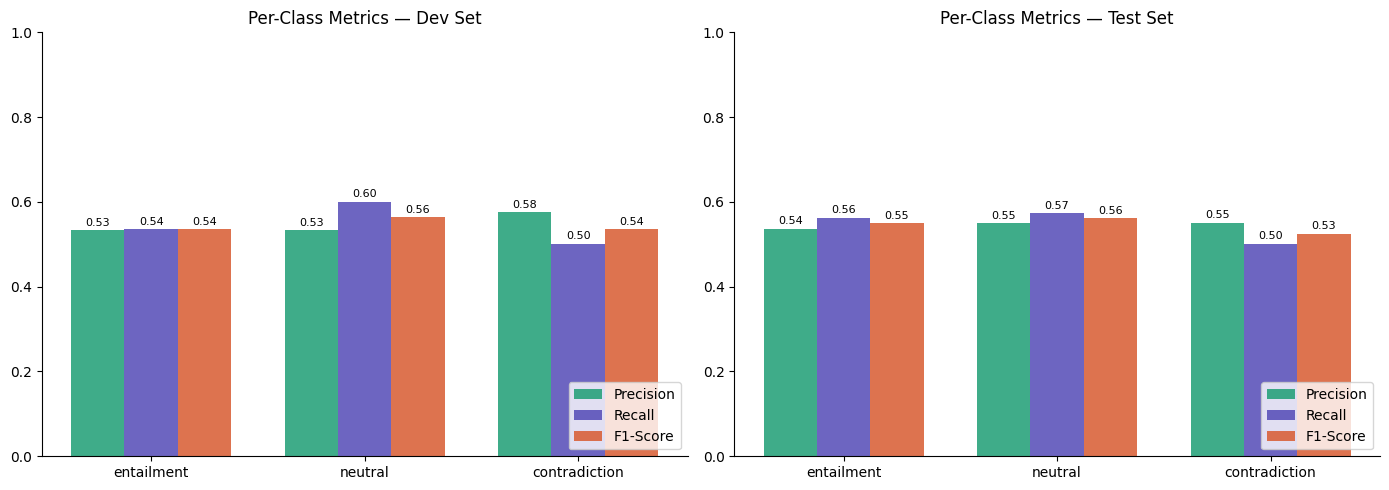

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in [
    (axes[0], dev_results, "Dev Set"),
    (axes[1], test_results, "Test Set"),
]:
    report = results["report"]
    metrics_df = pd.DataFrame({
        "Class": LABEL_NAMES,
        "Precision": [report[c]["precision"] for c in LABEL_NAMES],
        "Recall": [report[c]["recall"] for c in LABEL_NAMES],
        "F1-Score": [report[c]["f1-score"] for c in LABEL_NAMES],
    })

    x = np.arange(3)
    w = 0.25
    colors = ["#1D9E75", "#534AB7", "#D85A30"]

    for i, metric in enumerate(["Precision", "Recall", "F1-Score"]):
        bars = ax.bar(x + i * w, metrics_df[metric], w, label=metric,
                      color=colors[i], alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", fontsize=8)

    ax.set_xticks(x + w)
    ax.set_xticklabels(LABEL_NAMES)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"Per-Class Metrics — {title}")
    ax.legend(loc="lower right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## Error Analysis

In [16]:
# Add predictions to test dataframe
test_df["predicted"] = test_results["predictions"]
test_df["predicted_name"] = test_df["predicted"].map(LABEL_MAP)
test_df["correct"] = test_df["label"] == test_df["predicted"]
test_df["confidence"] = np.max(test_results["probabilities"], axis=1)
test_df["entailment_prob"] = test_results["probabilities"][:, 0]
test_df["neutral_prob"] = test_results["probabilities"][:, 1]
test_df["contradiction_prob"] = test_results["probabilities"][:, 2]

errors = test_df[~test_df["correct"]].copy()
correct = test_df[test_df["correct"]].copy()

print(f"Test set: {len(test_df)} examples")
print(f"Correct:  {len(correct)} ({len(correct)/len(test_df)*100:.1f}%)")
print(f"Errors:   {len(errors)} ({len(errors)/len(test_df)*100:.1f}%)")

Test set: 1000 examples
Correct:  546 (54.6%)
Errors:   454 (45.4%)


In [17]:
# === Linguistic Phenomena Tagging ===
# Same patterns from Phase 1 EDA

import re

def tag_phenomena(text):
    """Tag a hypothesis with linguistic phenomena it contains."""
    text_lower = text.lower()
    tags = []

    neg_patterns = r"\b(not|never|no|n't|neither|nor|nobody|nothing|nowhere|without|hardly|barely|seldom|rarely)\b"
    if re.search(neg_patterns, text_lower):
        tags.append("negation")

    if re.search(r"\b\d+\b", text) or re.search(r"\b(more|fewer|less|greater|twice|half|double|triple|percent|million|billion|hundred|thousand)\b", text_lower):
        tags.append("numerical")

    if re.search(r"\b(all|every|each|some|any|most|few|many|several|none|both)\b", text_lower):
        tags.append("quantifier")

    if re.search(r"\b(before|after|during|while|since|until|when|first|last|later|earlier|always|already|still|yet|recently|previously|formerly)\b", text_lower):
        tags.append("temporal")

    if re.search(r"\b(more|less|most|least|better|worse|best|worst|larger|smaller|bigger|higher|lower|longer|shorter|older|younger|faster|slower)\b", text_lower):
        tags.append("comparative")

    return tags if tags else ["surface_level"]

test_df["phenomena"] = test_df["hypothesis"].apply(tag_phenomena)
errors["phenomena"] = errors["hypothesis"].apply(tag_phenomena)

In [18]:
# === Error rate by phenomenon ===
from collections import Counter

all_phenom_counts = Counter()
error_phenom_counts = Counter()

for _, row in test_df.iterrows():
    for p in row["phenomena"]:
        all_phenom_counts[p] += 1
        if not row["correct"]:
            error_phenom_counts[p] += 1

phenomena_analysis = pd.DataFrame([
    {
        "Phenomenon": p,
        "Total": all_phenom_counts[p],
        "Errors": error_phenom_counts.get(p, 0),
        "Error Rate": error_phenom_counts.get(p, 0) / all_phenom_counts[p] * 100
    }
    for p in sorted(all_phenom_counts.keys())
]).sort_values("Error Rate", ascending=False)

print("=== Error Rate by Linguistic Phenomenon ===")
print(phenomena_analysis.to_string(index=False))

=== Error Rate by Linguistic Phenomenon ===
   Phenomenon  Total  Errors  Error Rate
   quantifier     57      29   50.877193
surface_level    450     217   48.222222
     negation     78      36   46.153846
  comparative     87      39   44.827586
    numerical    342     147   42.982456
     temporal    181      73   40.331492


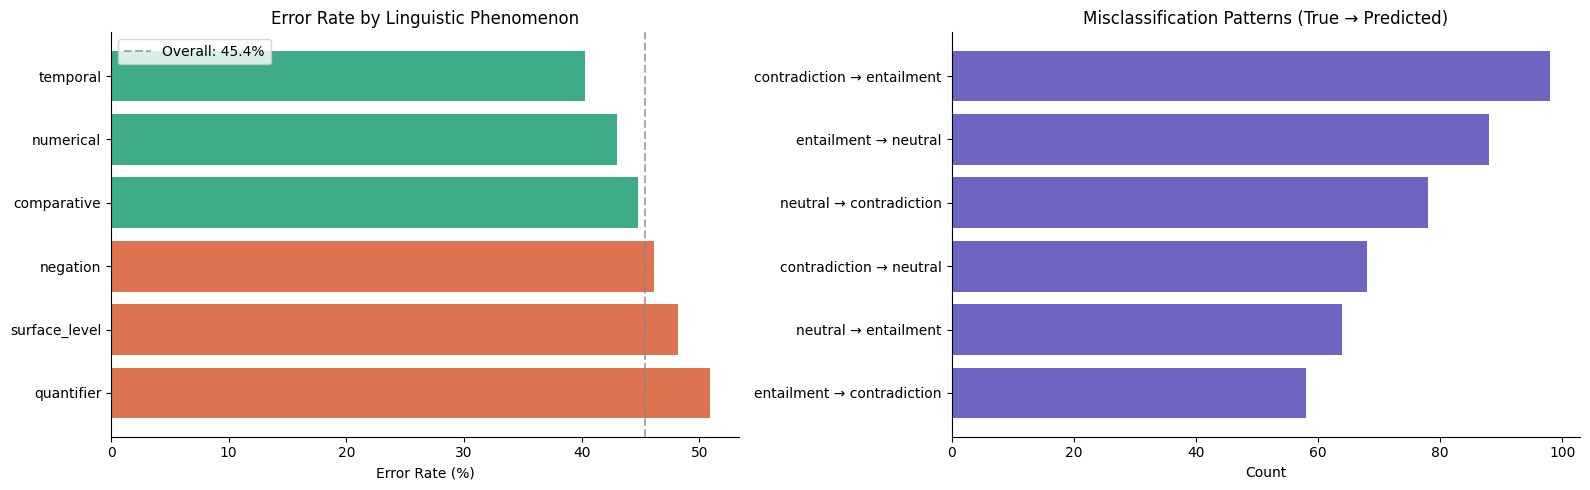

In [19]:
# Visualize error analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Error rate per phenomenon
ax = axes[0]
overall_error_rate = (1 - test_df["correct"].mean()) * 100
colors_phenom = ["#D85A30" if r > overall_error_rate else "#1D9E75"
                 for r in phenomena_analysis["Error Rate"]]

ax.barh(phenomena_analysis["Phenomenon"], phenomena_analysis["Error Rate"],
        color=colors_phenom, alpha=0.85)
ax.axvline(overall_error_rate, ls="--", color="#888", alpha=0.7,
           label=f"Overall: {overall_error_rate:.1f}%")
ax.set_xlabel("Error Rate (%)")
ax.set_title("Error Rate by Linguistic Phenomenon")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=10)

# Right: Confusion pattern for errors
ax = axes[1]
error_patterns = errors.groupby(["label_name", "predicted_name"]).size().reset_index(name="count")
error_patterns = error_patterns.sort_values("count", ascending=True)
pattern_labels = [f"{row['label_name']} → {row['predicted_name']}"
                  for _, row in error_patterns.iterrows()]
ax.barh(pattern_labels, error_patterns["count"], color="#534AB7", alpha=0.85)
ax.set_xlabel("Count")
ax.set_title("Misclassification Patterns (True → Predicted)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Confidence Analysis

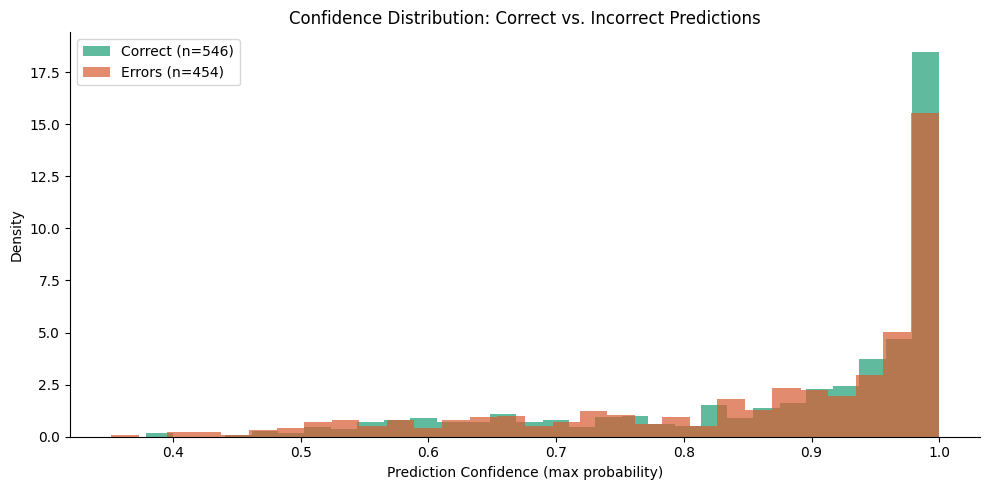

Mean confidence (correct):     0.883
Mean confidence (errors):      0.867
High-confidence errors (>0.9): 264 (58.1% of errors)


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(correct["confidence"], bins=30, alpha=0.7, color="#1D9E75",
        label=f"Correct (n={len(correct)})", density=True)
ax.hist(errors["confidence"], bins=30, alpha=0.7, color="#D85A30",
        label=f"Errors (n={len(errors)})", density=True)
ax.set_xlabel("Prediction Confidence (max probability)")
ax.set_ylabel("Density")
ax.set_title("Confidence Distribution: Correct vs. Incorrect Predictions")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean confidence (correct):     {correct['confidence'].mean():.3f}")
print(f"Mean confidence (errors):      {errors['confidence'].mean():.3f}")
print(f"High-confidence errors (>0.9): {(errors['confidence'] > 0.9).sum()} "
      f"({(errors['confidence'] > 0.9).sum() / len(errors) * 100:.1f}% of errors)")

## DeBERTa-v3-large Evaluation

In [21]:
LARGE_MODEL = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"

print(f"Loading {LARGE_MODEL}...")
try:
    tokenizer_large = AutoTokenizer.from_pretrained(LARGE_MODEL)
    print("Loaded large tokenizer via AutoTokenizer")
except Exception as e:
    print(f"AutoTokenizer failed: {e}")
    spm_path_large = hf_hub_download(repo_id=LARGE_MODEL, filename="spm.model")
    tokenizer_large = DebertaV2Tokenizer(vocab_file=spm_path_large, do_lower_case=False)
    print("Loaded large tokenizer via DebertaV2Tokenizer")

model_large = AutoModelForSequenceClassification.from_pretrained(LARGE_MODEL)
model_large.to(device)
model_large.eval()

Loading MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/395 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loaded large tokenizer via AutoTokenizer


model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 1024, padding_idx=0)
      (LayerNorm): LayerNorm((1024,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-23): 24 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (key_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (value_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNo

In [22]:
print(f"Model label mapping: {model_large.config.id2label}")

Model label mapping: {0: 'entailment', 1: 'neutral', 2: 'contradiction'}


In [23]:
# Build remap for large model
model_large_id2label = model_large.config.id2label
REMAP_LARGE = {}
for model_idx, label_str in model_large_id2label.items():
    model_idx = int(model_idx)
    label_lower = label_str.lower()
    if "entail" in label_lower:
        REMAP_LARGE[model_idx] = 0
    elif "neutral" in label_lower:
        REMAP_LARGE[model_idx] = 1
    elif "contra" in label_lower:
        REMAP_LARGE[model_idx] = 2

print(f"Remap (large): {REMAP_LARGE}")

large_params = sum(p.numel() for p in model_large.parameters())
print(f"Parameters: {large_params:,}")

Remap (large): {0: 0, 1: 1, 2: 2}
Parameters: 435,064,835


In [24]:
def run_inference_model(model_obj, tok, remap, premises, hypotheses, batch_size=16):
    """Run batched inference with a specified model, tokenizer, and label remap."""
    all_logits = []

    for i in range(0, len(premises), batch_size):
        batch_p = premises[i:i+batch_size]
        batch_h = hypotheses[i:i+batch_size]

        inputs = tok(
            batch_p, batch_h,
            max_length=CONFIG["max_length"],
            truncation=True,
            padding=True,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            outputs = model_obj(**inputs)

        all_logits.append(outputs.logits.cpu())

        if (i // batch_size) % 10 == 0:
            print(f"  Processed {min(i+batch_size, len(premises))}/{len(premises)}")

    logits = torch.cat(all_logits, dim=0)
    probs = torch.softmax(logits, dim=-1).numpy()

    model_preds = np.argmax(logits.numpy(), axis=-1)
    anli_preds = np.array([remap[p] for p in model_preds])

    anli_probs = np.zeros_like(probs)
    for midx, aidx in remap.items():
        anli_probs[:, aidx] = probs[:, midx]

    return anli_preds, anli_probs

In [25]:
print("Running large model inference on Dev set...")
dev_preds_large, dev_probs_large = run_inference_model(
    model_large, tokenizer_large, REMAP_LARGE,
    dev_df["premise"].tolist(), dev_df["hypothesis"].tolist(),
    batch_size=16,  # Smaller batch — large model uses more memory
)

print("\nRunning large model inference on Test set...")
test_preds_large, test_probs_large = run_inference_model(
    model_large, tokenizer_large, REMAP_LARGE,
    test_df["premise"].tolist(), test_df["hypothesis"].tolist(),
    batch_size=16,
)

dev_results_large = evaluate_results(dev_labels, dev_preds_large, dev_probs_large, "Dev (Large)")
test_results_large = evaluate_results(test_labels, test_preds_large, test_probs_large, "Test (Large)")


Running large model inference on Dev set...
  Processed 16/1000
  Processed 176/1000
  Processed 336/1000
  Processed 496/1000
  Processed 656/1000
  Processed 816/1000
  Processed 976/1000

Running large model inference on Test set...
  Processed 16/1000
  Processed 176/1000
  Processed 336/1000
  Processed 496/1000
  Processed 656/1000
  Processed 816/1000
  Processed 976/1000

  DEV (LARGE) SET RESULTS
Accuracy: 0.6920 (69.20%)

               precision    recall  f1-score   support

   entailment     0.7040    0.7335    0.7185       334
      neutral     0.6788    0.6727    0.6757       333
contradiction     0.6925    0.6697    0.6809       333

     accuracy                         0.6920      1000
    macro avg     0.6918    0.6920    0.6917      1000
 weighted avg     0.6918    0.6920    0.6917      1000


  TEST (LARGE) SET RESULTS
Accuracy: 0.6820 (68.20%)

               precision    recall  f1-score   support

   entailment     0.6919    0.7126    0.7021       334
      neut

In [26]:
# Free large model memory
del model_large
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Large model unloaded to free memory.")

Large model unloaded to free memory.


## Model Comparison Table

In [27]:
# === UPDATE THESE WITH YOUR ACTUAL PHASE 2 RESULTS ===
baseline_results = {
    "Random Baseline":       {"dev_acc": 0.333, "test_acc": 0.333, "dev_f1": 0.333, "test_f1": 0.333},
    "Majority Baseline":     {"dev_acc": 0.340, "test_acc": 0.340, "dev_f1": 0.170, "test_f1": 0.170},
    "TF-IDF + LogReg":       {"dev_acc": 0.000, "test_acc": 0.000, "dev_f1": 0.000, "test_f1": 0.000},  # Fill in
    "BERT-base":             {"dev_acc": 0.000, "test_acc": 0.000, "dev_f1": 0.000, "test_f1": 0.000},  # Fill in
}

# Add DeBERTa-v3 results
baseline_results["DeBERTa-v3-base\n(MNLI+FEVER+ANLI)"] = {
    "dev_acc": dev_results["accuracy"],
    "test_acc": test_results["accuracy"],
    "dev_f1": dev_results["report"]["macro avg"]["f1-score"],
    "test_f1": test_results["report"]["macro avg"]["f1-score"],
}

baseline_results["DeBERTa-v3-large\n(MNLI+FEVER+ANLI+LingNLI+WANLI)"] = {
    "dev_acc": dev_results_large["accuracy"],
    "test_acc": test_results_large["accuracy"],
    "dev_f1": dev_results_large["report"]["macro avg"]["f1-score"],
    "test_f1": test_results_large["report"]["macro avg"]["f1-score"],
}

comparison_df = pd.DataFrame(baseline_results).T
comparison_df.columns = ["Dev Acc", "Test Acc", "Dev F1", "Test F1"]
comparison_df = comparison_df.round(4)

print("=" * 70)
print("  MODEL COMPARISON — ANLI Round 2")
print("=" * 70)
print(comparison_df.to_string())

  MODEL COMPARISON — ANLI Round 2
                                                   Dev Acc  Test Acc  Dev F1  Test F1
Random Baseline                                      0.333     0.333  0.3330   0.3330
Majority Baseline                                    0.340     0.340  0.1700   0.1700
TF-IDF + LogReg                                      0.000     0.000  0.0000   0.0000
BERT-base                                            0.000     0.000  0.0000   0.0000
DeBERTa-v3-base\n(MNLI+FEVER+ANLI)                   0.546     0.546  0.5454   0.5455
DeBERTa-v3-large\n(MNLI+FEVER+ANLI+LingNLI+WANLI)    0.692     0.682  0.6917   0.6820


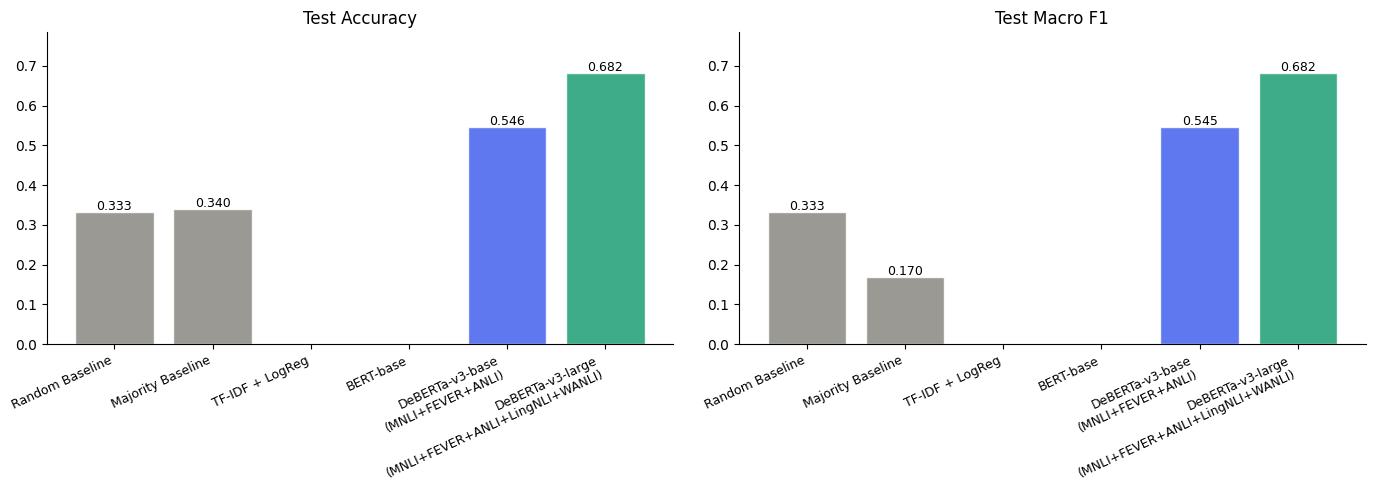

In [28]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = comparison_df.index.tolist()
x = np.arange(len(models))
# Gray for baselines, blue for DeBERTa-base, green for DeBERTa-large
colors_bar = ["#888780"] * (len(models) - 2) + ["#4361ee", "#1D9E75"]

for ax, col, title in [
    (axes[0], "Test Acc", "Test Accuracy"),
    (axes[1], "Test F1", "Test Macro F1"),
]:
    vals = comparison_df[col].values
    bars = ax.bar(x, vals, color=colors_bar, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right", fontsize=9)
    ax.set_ylim(0, max(vals) * 1.15 if max(vals) > 0 else 1.0)
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()